In [2]:
from wget import download
from os import path
import pandas as pd

if not path.exists("ObesityDataSet_raw_and_data_sinthetic.csv"):
    download("https://ignaciorlando.github.io/datasets/data-science/ObesityDataSet_raw_and_data_sinthetic.csv")
else:
    print("The file ObesityDataSet_raw_and_data_sinthetic.csv already exists.")

if not path.exists("ObesityDataSet_raw_and_data_sinthetic.txt"):
    download("https://ignaciorlando.github.io/datasets/data-science/ObesityDataSet_raw_and_data_sinthetic.txt")
else:
    print("The file ObesityDataSet_raw_and_data_sinthetic.txt already exists.")

The file ObesityDataSet_raw_and_data_sinthetic.csv already exists.
The file ObesityDataSet_raw_and_data_sinthetic.txt already exists.


In [3]:
with open("ObesityDataSet_raw_and_data_sinthetic.txt", "r", encoding="utf-8") as file:
    content = file.read()
    print(content)


Obesidad

La obesidad, que causa problemas físicos y mentales, es un problema de salud global con graves consecuencias. La prevalencia de la obesidad aumenta constantemente, por lo que se necesita nueva investigación que examine los factores que influyen en la obesidad y cómo predecir la aparición de la condición según estos factores.

Los datos fueron recolectados como parte de este trabajo científico: https://www.sciencedirect.com/science/article/pii/S2352340919306985#sec1

Información del Conjunto de Datos

Este conjunto de datos incluye información para la estimación de los niveles de obesidad en individuos de los países de México, Perú y Colombia, en función de sus hábitos alimenticios y condición física. Los datos contienen 17 atributos y 2111 registros, los registros están etiquetados con la variable de clase NObesidad (Nivel de Obesidad), que permite la clasificación de los datos utilizando los valores de Peso Insuficiente, Peso Normal, Sobrepeso Nivel I, Sobrepeso Nivel II, Ob

In [4]:
leer_datos_obesidad = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
leer_datos_obesidad.head()

,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,SCC,SMOKE,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,21.0,Female,1.62,64.0,no,no,2.0,3.0,no,no,2.0,yes,0.0,1.0,Sometimes,Public_Transportation,Normal_Weight
1,21.0,Female,1.52,56.0,Sometimes,no,3.0,3.0,yes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,23.0,Male,1.80,77.0,Frequently,no,2.0,3.0,no,no,2.0,yes,2.0,1.0,Sometimes,Public_Transportation,Normal_Weight
3,27.0,Male,1.80,87.0,Frequently,no,3.0,3.0,no,no,2.0,no,2.0,0.0,Sometimes,Walking,Overweight_Level_I
4,22.0,Male,1.78,89.8,Sometimes,no,2.0,1.0,no,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [5]:
leer_datos_obesidad.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             2111 non-null   float64
 1   Gender                          2111 non-null   str    
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   CALC                            2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   SCC                             2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  family_history_with_overweight  2111 non-null   str    
 12  FAF                             2111 non-null

In [6]:
leer_datos_obesidad["Age"] = leer_datos_obesidad["Age"].astype(int)
leer_datos_obesidad["NCP"] = leer_datos_obesidad["NCP"].astype(int)

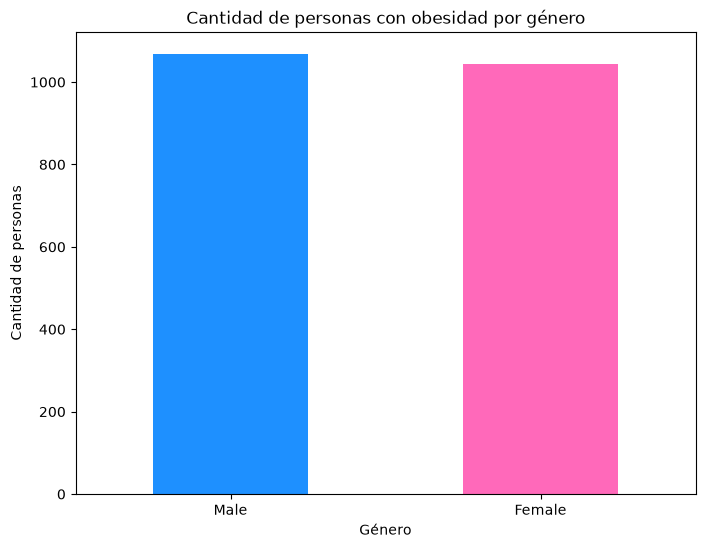

In [7]:
import matplotlib.pyplot as plt

cantidad_genero_obesidad = leer_datos_obesidad["Gender"].value_counts()

plt.figure(figsize=(8, 6))

cantidad_genero_obesidad.plot(kind="bar", color=[ "#1E90FF","#FF69Ba"])

plt.title("Cantidad de personas con obesidad por género")
plt.xlabel("Género")
plt.ylabel("Cantidad de personas")
plt.xticks(rotation=0)

plt.show()

Se observa una distribución bastante equilibrada entre ambos grupos, aunque la cantidad de hombres es ligeramente superior a la de mujeres.

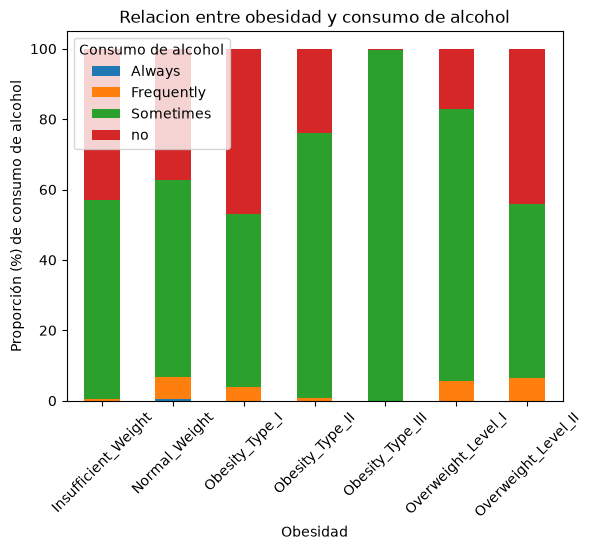

In [8]:
#proporcion_alcohol_obesidad = pd.crosstab(leer_datos_obesidad["Gender"], leer_datos_obesidad["CALC"],normalize="index")*100
proporcion_alcohol_obesidad = pd.crosstab(leer_datos_obesidad["NObeyesdad"],  leer_datos_obesidad["CALC"], normalize="index")*100

proporcion_alcohol_obesidad.plot(kind="bar", stacked=True)

# plt.title("Proporción de consumo de alcohol por género")
# plt.xlabel("Género")
# plt.ylabel("Proporción (%) de consumo de alcohol")
# plt.xticks(rotation=0)

# plt.legend(title="Consumo de alcohol")

plt.title("Relacion entre obesidad y consumo de alcohol")
plt.xlabel("Obesidad")
plt.ylabel("Proporción (%) de consumo de alcohol")
plt.xticks(rotation=45)

plt.legend(title="Consumo de alcohol")

plt.show()

En ambos géneros, la categoría más frecuente es Sometimes. Aproximadamente el 30% no consume alcohol. No hubo alguno que no haya tomado alcohol. El consumo Frequently es relativamente poco frecuente en ambos grupos. En general, los patrones de consumo son similares entre ambos géneros, aunque los hombres presentan una proporción ligeramente mayor de consumo frecuente. 

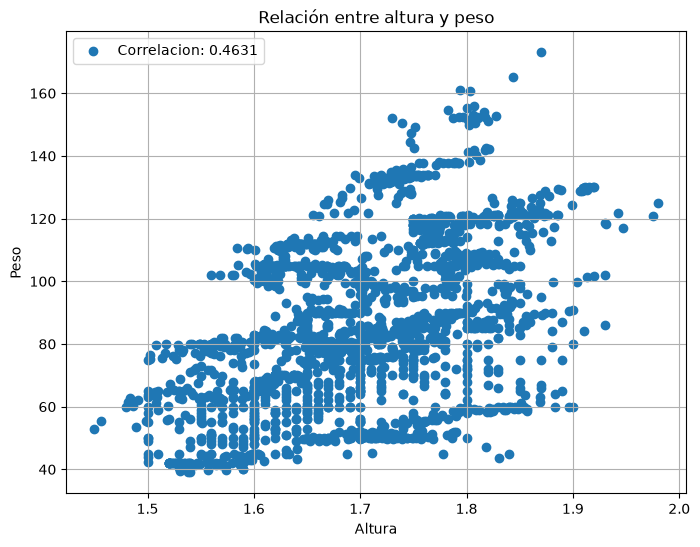

In [9]:
from scipy import stats

#edad_obesidad = leer_datos_obesidad["Age"]
peso_obesidad = leer_datos_obesidad["Weight"]
altura_obesidad = leer_datos_obesidad["Height"]

plt.figure(figsize=(8, 6))
plt.scatter(altura_obesidad, peso_obesidad)
plt.title("Relación entre altura y peso")
plt.xlabel("Altura")
plt.ylabel("Peso")
coeficiente_correlacion_obesidad, _ = stats.pearsonr(altura_obesidad, peso_obesidad)
plt.legend([f"Correlacion: {coeficiente_correlacion_obesidad:.4f}"], loc = "upper left")
plt.grid(True)
plt.show()

Al analizar la relación entre la edad y el peso mediante un gráfico de dispersión, se observa una tendencia positiva leve. El coeficiente de correlación obtenido es aproximadamente 0,20, lo que indica una correlación positiva débil entre ambas variables. Por lo tanto, aunque existe cierta tendencia a que el peso aumente con la edad, la relación no es suficientemente fuerte como para afirmar que la edad sea un factor determinante del peso. La dispersión de los datos muestra que personas con edades similares pueden presentar pesos considerablemente diferentes.

Al analizar la relacion entre la altura y el peso mediante un grafico de dispersion, se observa una tendencia positiva. El coeficiente de correlacion (0.46) se puede observar una correlacion positiva, Por lo tanto, exixte una cierta tendencia a que el peso aumente con la altura, aunque no es tan fuerte en algunas observaciones pero existe cierta relacion.

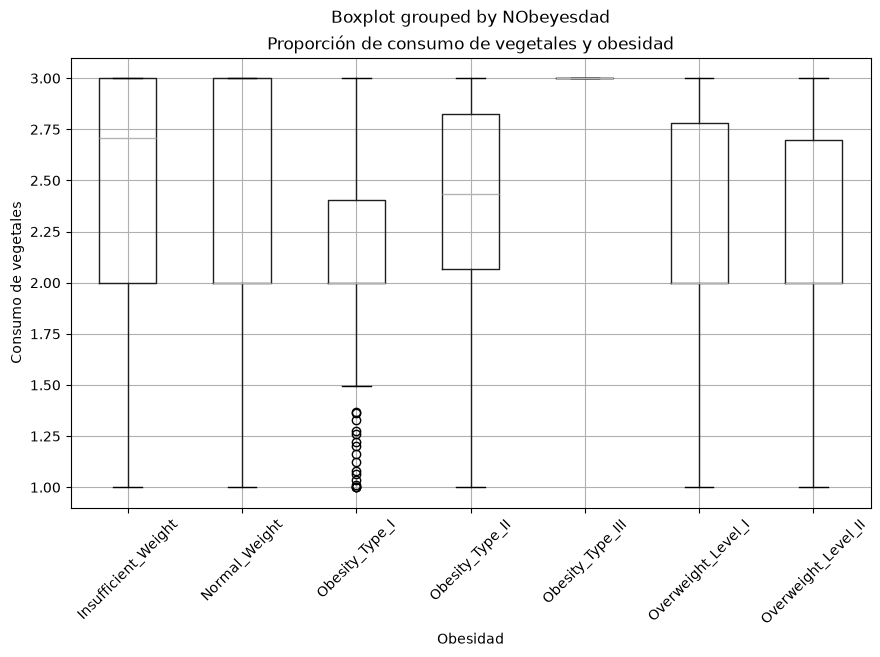

In [10]:
#plt.figure(figsize=(8,6))
# plt.boxplot([leer_datos_obesidad[leer_datos_obesidad["Gender"] == "Female"]["Age"],
#             leer_datos_obesidad[leer_datos_obesidad["Gender"] == "Male"]["Age"]],
#             tick_labels=["Muejeres", "Hombres"])

#leer_datos_obesidad.boxplot(column="Weight", by="NObeyesdad", figsize=(8,6))

leer_datos_obesidad.boxplot(column="FCVC", by="NObeyesdad", figsize=(10,6))

# plt.xlabel("Genero")
# plt.ylabel("Edad")

plt.xlabel("Obesidad")
plt.ylabel("Consumo de vegetales")

#plt.title("Proporción de edades en la muestra de mujeres y de hombres")
plt.title("Proporción de consumo de vegetales y obesidad")
plt.xticks(rotation = 45)

plt.show()

Al analizar la distribución de edades de mujeres y hombres, se observa que ambos grupos presentan una distribución etaria similar. Esto se debe a que las proporciones de personas pertenecientes a los distintos rangos de edad son semejantes entre ambos géneros.

Además, la cantidad de mujeres (1043) y hombres (1068) es muy similar, por lo que la comparación entre ambos grupos resulta adecuada.

En conclusión, las distribuciones de edades de mujeres y hombres son similares, ya que no se observan diferencias importantes en la proporción de personas pertenecientes a los distintos rangos de edad.

Al analizar la distribución del peso según la categoría de obesidad, se observa una tendencia creciente del peso a medida que aumenta el nivel de obesidad. Las categorías de menor nivel presentan, en general, valores de peso inferiores, mientras que las categorías de obesidad presentan valores de peso progresivamente mayores.

Por lo tanto, existe una relación clara entre el peso y la categoría de obesidad. Esto resulta coherente con la clasificación utilizada en el conjunto de datos, ya que las categorías de obesidad representan diferentes niveles de exceso de peso.

El gráfico permite observar si la distribución del consumo de vegetales cambia entre las diferentes categorías de obesidad. Si las proporciones presentan diferencias entre categorías, puede decirse que existe una asociación entre ambas variables. Sin embargo, esto no permite afirmar que el consumo de vegetales sea la causa de un determinado nivel de obesidad, ya que pueden intervenir otros factores.

Por lo tanto, el análisis permite estudiar una posible relación entre la frecuencia de consumo de vegetales y la categoría de obesidad, pero no establecer una relación causal.

# Ejercicio 2

In [11]:
if not path.exists("netflix_titles.csv"):
    download("https://ignaciorlando.github.io/datasets/data-science/netflix_titles.csv")
else: 
    print("El archivo ya existe")

El archivo ya existe


In [12]:
leer_datos_netflix = pd.read_csv("netflix_titles.csv", encoding="latin-1")
leer_datos_netflix.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
leer_datos_netflix = leer_datos_netflix.loc[:, ~leer_datos_netflix.columns.str.startswith("Unnamed")]
leer_datos_netflix.shape
leer_datos_netflix.info()

<class 'pandas.DataFrame'>
RangeIndex: 8809 entries, 0 to 8808
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8809 non-null   str  
 1   type          8809 non-null   str  
 2   title         8809 non-null   str  
 3   director      6175 non-null   str  
 4   cast          7984 non-null   str  
 5   country       7978 non-null   str  
 6   date_added    8799 non-null   str  
 7   release_year  8809 non-null   int64
 8   rating        8805 non-null   str  
 9   duration      8806 non-null   str  
 10  listed_in     8809 non-null   str  
 11  description   8809 non-null   str  
dtypes: int64(1), str(11)
memory usage: 826.0 KB


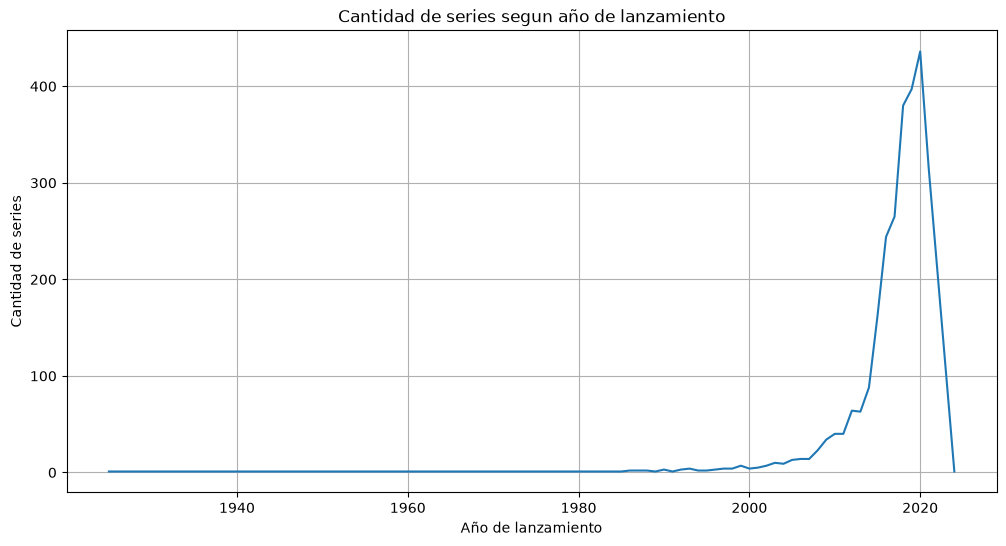

In [15]:
peliculas_por_anio = leer_datos_netflix.groupby("release_year").size()
tv_shows = leer_datos_netflix[leer_datos_netflix["type"] == "TV Show"]
tv_shows_por_anio = tv_shows.groupby("release_year").size()

plt.figure(figsize=(12,6))
# plt.plot(peliculas_por_anio.index, peliculas_por_anio.values)
# plt.xlabel("Año de lanzamiento")
# plt.ylabel("Cantidad de peliculas")
# plt.title("Cantidad de peliculas segun año de lanzamiento")

plt.plot(tv_shows_por_anio.index, tv_shows_por_anio.values)
plt.xlabel("Año de lanzamiento")
plt.ylabel("Cantidad de series")
plt.title("Cantidad de series segun año de lanzamiento")

plt.grid(True)
plt.show()

El catálogo está compuesto principalmente por títulos relativamente recientes, observándose un fuerte crecimiento en la cantidad de contenidos correspondientes a los años más cercanos al momento de creación del catálogo.
Se observa que la cantidad de títulos es relativamente baja para los años más antiguos y aumenta progresivamente a partir de la década de 2000. El crecimiento se vuelve especialmente marcado a partir de 2015 aprox.

Al analizar únicamente los TV Shows, se observa que la cantidad de títulos aumenta considerablemente a partir de 2014 aprox. Luego se produce una disminución en 2021 aprox. Al igual que en el análisis general del catálogo, los TV Shows más recientes representan una proporción importante de los contenidos registrados. Esto indica que el catálogo contiene principalmente series cuyo año de lanzamiento pertenece a los últimos años del período analizado.


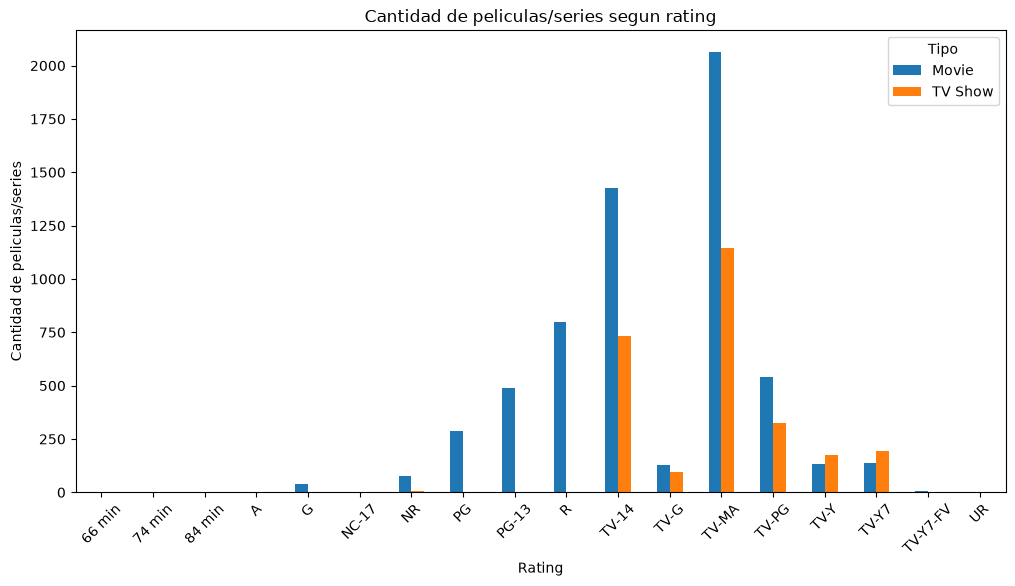

In [16]:
peliculas_series_rating = pd.crosstab(leer_datos_netflix["rating"], leer_datos_netflix["type"])

peliculas_series_rating.plot(kind="bar", figsize=(12,6))

plt.xlabel("Rating")
plt.ylabel("Cantidad de peliculas/series")
plt.title("Cantidad de peliculas/series segun rating")
plt.legend(title = "Tipo")
plt.xticks(rotation=45)
plt.show()

Al analizar la cantidad de películas y TV Shows según su rating, se observa que las categorías TV-MA y TV-14 son las más frecuentes en el catálogo. En ambos casos existe una mayor cantidad de películas que de TV Shows.

También se observan diferencias entre los tipos de contenido: algunos ratings, como PG y PG-13, aparecen exclusivamente en películas, mientras que las categorías destinadas específicamente a contenidos televisivos tienen una presencia importante en los TV Shows.

Por lo tanto, la distribución de los ratings no es igual para películas y TV Shows, aunque en ambos tipos de contenido predominan las categorías TV-MA y TV-14.

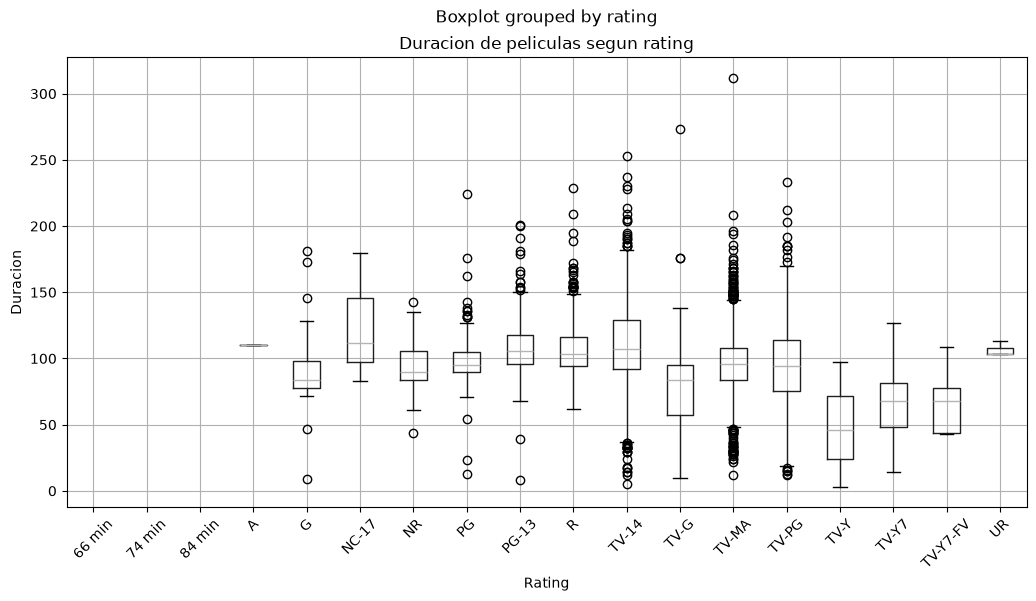

In [ ]:
peliculas = leer_datos_netflix[leer_datos_netflix["type"] == "Movie"].copy()

peliculas["duracion_min"] = pd.to_numeric(peliculas["duration"].str.extract(r"(\d+)")[0], errors="coerce")

peliculas.boxplot(column="duracion_min", by="rating", figsize=(12,6))
plt.xlabel("Rating")
plt.ylabel("Duracion")
plt.title("Duracion de peliculas segun rating")
plt.xticks(rotation=45)
plt.show()

Para estudiar la relación entre el rating y la duración fue necesario analizar por separado las películas y los TV Shows, debido a que la duración se expresa en minutos para las películas y en cantidad de temporadas para los TV Shows.

En el caso de las películas, se observa que la duración presenta diferencias entre las distintas categorías de rating. Algunas categorías, como TV-14, PG-13 y R, presentan duraciones promedio mayores que otras categorías.

Por lo tanto, se observa una asociación entre el rating y la distribución de la duración de las películas. Sin embargo, no puede afirmarse que exista una relación causal, ya que el rating es una variable categórica y la duración puede depender de otros factores.

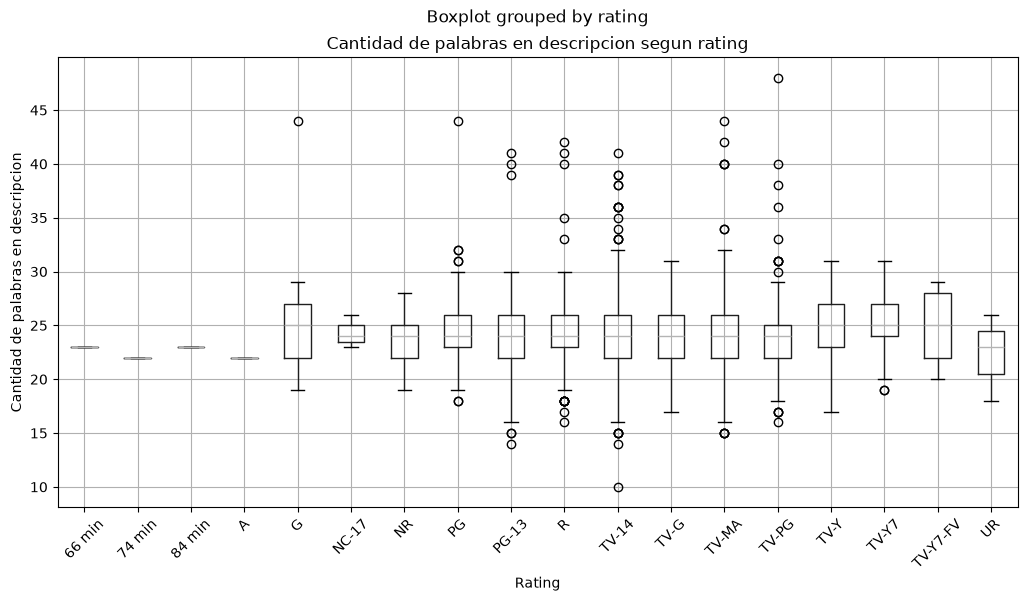

In [21]:
leer_datos_netflix["cantidad_palabras"] = (leer_datos_netflix["description"].fillna("").str.split().str.len())
peliculas = leer_datos_netflix[leer_datos_netflix["type"] == "Movie"].copy()
peliculas.boxplot(column="cantidad_palabras", by="rating", figsize=(12,6))
plt.xlabel("Rating")
plt.ylabel("Cantidad de palabras en descripcion")
plt.title("Cantidad de palabras en descripcion segun rating")
plt.xticks(rotation=45)
plt.show()

Al analizar la cantidad de palabras de las descripciones de las películas según su rating, se observan diferencias relativamente pequeñas entre las distintas categorías.

Sin embargo, no podemos afirmar que las películas con descripciones más largas estén mejor votadas. Esto se debe a que la variable rating del conjunto de datos representa la clasificación del contenido y no una puntuación otorgada por los espectadores.

Por lo tanto, el análisis permite estudiar si existe una diferencia en la longitud de las descripciones según la clasificación, pero no permite determinar si una película está mejor valorada que otra en función de la cantidad de palabras de su descripción.

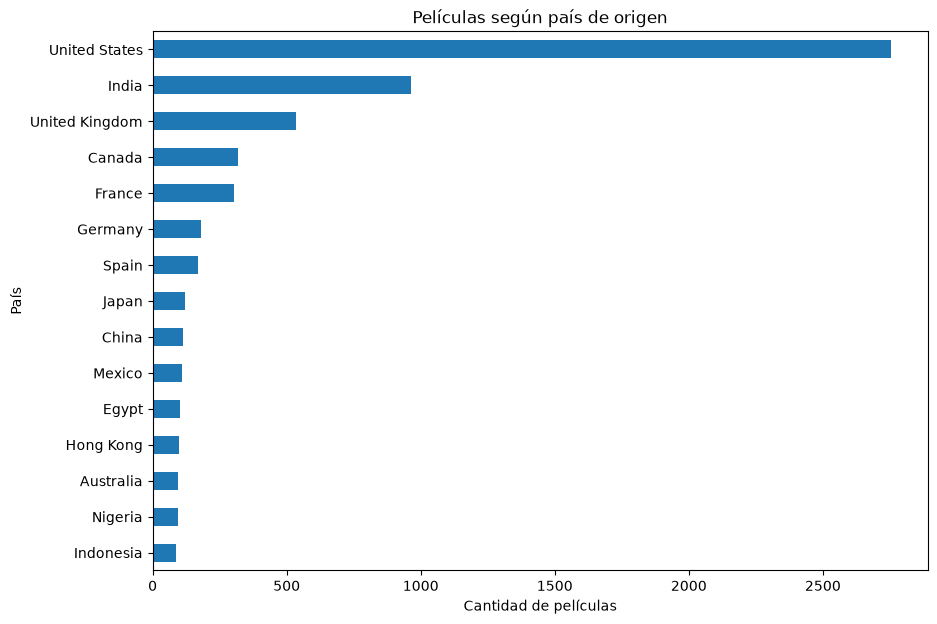

In [24]:
peliculas = leer_datos_netflix[leer_datos_netflix["type"] == "Movie"]

paises_peliculas = (peliculas["country"].dropna().str.split(",").explode().str.strip().value_counts())

paises_peliculas.head(15).sort_values().plot(kind="barh", figsize=(10, 7))

plt.xlabel("Cantidad de películas")
plt.ylabel("País")
plt.title("Películas según país de origen")
plt.show()

Al analizar la cantidad de películas y TV Shows según el país de origen, se observa que Estados Unidos es el país que presenta la mayor cantidad de contenidos en ambos tipos.

En el caso de las películas, Estados Unidos presenta una diferencia considerable respecto de India, que ocupa el segundo lugar. Para los TV Shows, Estados Unidos también ocupa el primer lugar, seguido por Reino Unido y Japón.

Por lo tanto, Estados Unidos tiene una presencia predominante en el catálogo analizado. También se observa una diferencia en los países que tienen mayor participación según el tipo de contenido: India tiene una presencia muy importante en películas, mientras que Japón y Corea del Sur tienen una participación destacada entre los TV Shows.

Debe tenerse en cuenta que algunos contenidos tienen más de un país de origen, por lo que un mismo título puede contabilizarse en más de un país.

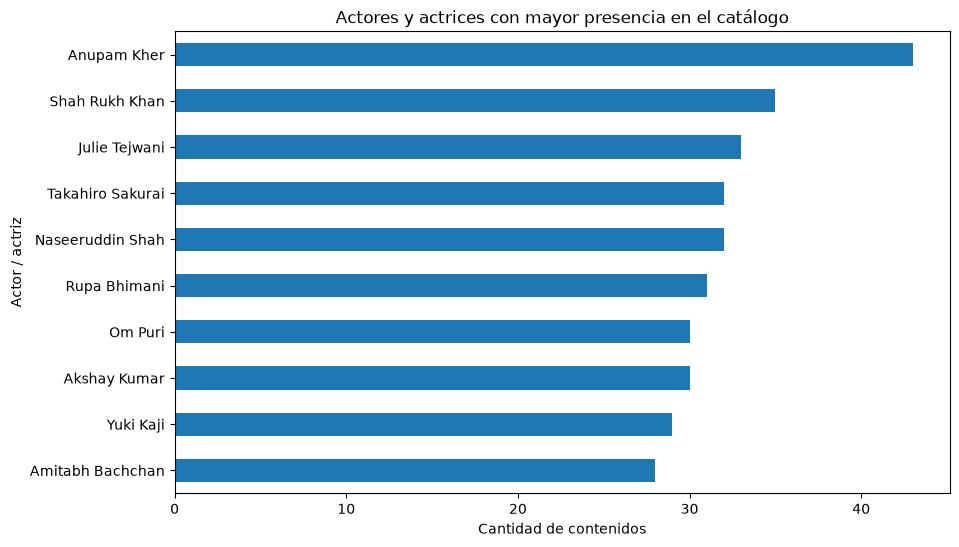

In [25]:
actores = (leer_datos_netflix["cast"].dropna().str.split(",").explode().str.strip())
cantidad_actores = actores.value_counts()
top_10_actores = cantidad_actores.head(10).sort_values()

top_10_actores.plot(kind="barh", figsize=(10, 6))

plt.xlabel("Cantidad de contenidos")
plt.ylabel("Actor / actriz")
plt.title("Actores y actrices con mayor presencia en el catálogo")
plt.show()

Al analizar la cantidad de contenidos en los que participa cada integrante del casting, se observa que Anupam Kher es el actor que aparece en mayor cantidad de títulos del catálogo, seguido por Shah Rukh Khan y Julie Tejwani.

Para realizar este análisis fue necesario separar los distintos integrantes del casting que se encontraban almacenados en una misma celda. Luego se contabilizó la cantidad de apariciones de cada actor y se seleccionaron los diez que presentan mayor frecuencia.

Por lo tanto, el gráfico permite identificar cuáles son los actores y actrices con mayor presencia dentro del catálogo analizado.

# Ejercicio 3

In [26]:
import zipfile

if not path.exists("food.zip"):
    download("https://ignaciorlando.github.io/datasets/data-science/food.zip")
else:
    print("File already exists, skipping download.")

with zipfile.ZipFile("food.zip", 'r') as zip_ref:
    zip_ref.extractall()

leer_datos_food = pd.read_csv("food_coded.csv")

leer_datos_food.head()

,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,...,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
0,2.4,2,1,430,NaN,315.0,1,none,we dont have comfort,9.0,...,1.0,1.0,1,1165.0,345,car racing,5,1,1315,187
1,3.654,1,1,610,3.0,420.0,2,"chocolate, chips, ice cream","Stress, bored, anger",1.0,...,1.0,1.0,2,725.0,690,Basketball,4,2,900,155
2,3.3,1,1,720,4.0,420.0,2,"frozen yogurt, pizza, fast food","stress, sadness",1.0,...,1.0,2.0,5,1165.0,500,none,5,1,900,I'm not answering this.
3,3.2,1,1,430,3.0,420.0,2,"Pizza, Mac and cheese, ice cream",Boredom,2.0,...,1.0,2.0,5,725.0,690,NaN,3,1,1315,"Not sure, 240"
4,3.5,1,1,720,2.0,420.0,2,"Ice cream, chocolate, chips","Stress, boredom, cravings",1.0,...,1.0,1.0,4,940.0,500,Softball,4,2,760,190


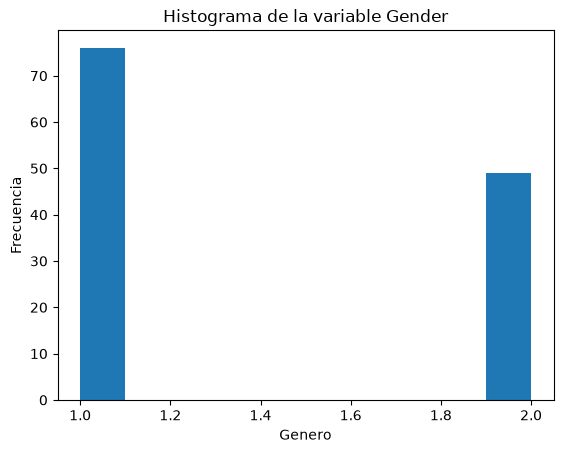

In [32]:
#distribución de algunos valores de variable en la muestra
bins=10

plt.hist(leer_datos_food["Gender"], bins=bins)

plt.xlabel("Genero")
plt.ylabel("Frecuencia")
plt.title("Histograma de la variable Gender")
plt.show()



En la muestra se observa una distribución de participantes según género. El gráfico de barras permite comparar visualmente la cantidad de mujeres y hombres y determinar si existe un predominio de alguno de los dos grupos.

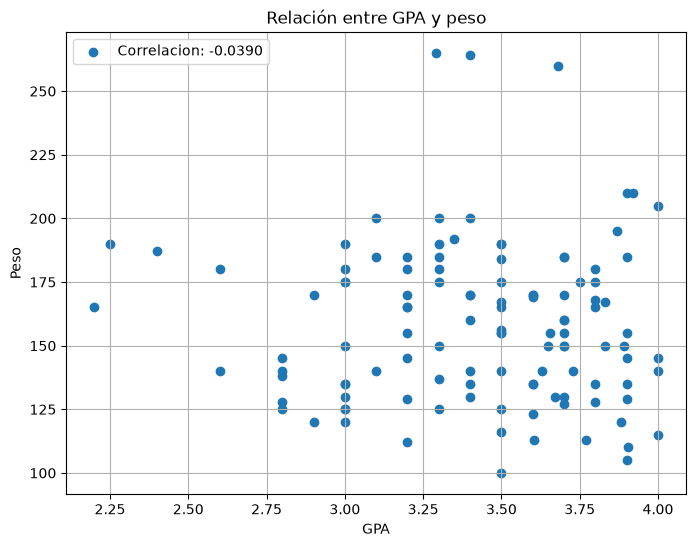

In [38]:
#relación entre dos variables cuantitativas
leer_datos_food["weight"] = pd.to_numeric(leer_datos_food["weight"],errors="coerce")
leer_datos_food["GPA"] = pd.to_numeric(leer_datos_food["GPA"],errors="coerce")
datos_cuantitativos = leer_datos_food[["GPA", "weight"]].dropna()

plt.figure(figsize=(8, 6))

plt.scatter(datos_cuantitativos["GPA"],datos_cuantitativos["weight"])
coeficiente_correlacion, _ = stats.pearsonr(datos_cuantitativos["GPA"],datos_cuantitativos["weight"])
plt.legend([f"Correlacion: {coeficiente_correlacion:.4f}"], loc="upper left")

plt.xlabel("GPA")
plt.ylabel("Peso")
plt.title("Relación entre GPA y peso")
plt.grid(True)
plt.show()

El gráfico de dispersión permite observar si existe alguna tendencia entre el promedio académico y el peso de los participantes. Si los puntos se encuentran muy dispersos y no siguen una dirección clara, podemos concluir que no se observa una relación fuerte entre ambas variables.

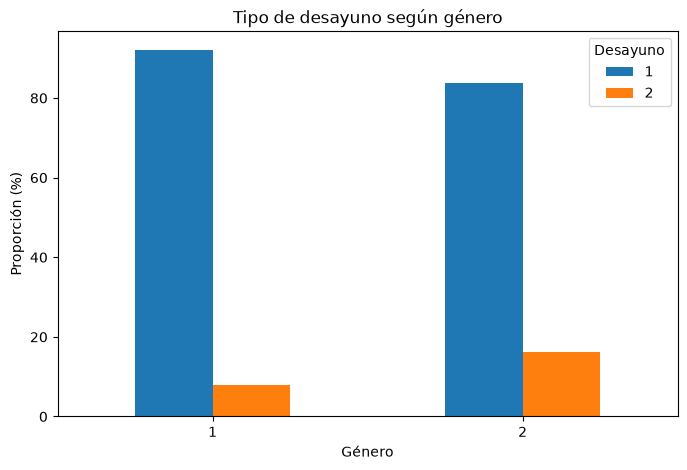

In [39]:
#relaciones entre dos variables cualitativas
tabla_genero_desayuno = pd.crosstab(leer_datos_food["Gender"],leer_datos_food["breakfast"], normalize="index")*100
tabla_genero_desayuno.plot(kind="bar",figsize=(8, 5))


plt.xlabel("Género")
plt.ylabel("Proporción (%)")
plt.title("Tipo de desayuno según género")
plt.xticks(rotation=0)
plt.legend(title="Desayuno")
plt.show()


La tabla de contingencia y el gráfico de proporciones permiten comparar el tipo de desayuno elegido por hombres y mujeres. Si las proporciones son similares, podemos decir que no se observa una diferencia importante en la elección del desayuno según género. Si las proporciones son diferentes, podemos hablar de una posible asociación entre ambas variables.